In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
titanic = sns.load_dataset("titanic")

In [4]:
print(titanic.head())
print("------------")
print(titanic.describe())
print("------------")
print(titanic.info())
print("------------")
print(titanic.isnull().sum())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
------------
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523

In [5]:
features = ["pclass", "sex", "age", "fare", "embarked"]
target = ["survived"]

In [6]:
# handling missing data
# numerical values ke liye hum mean, median use karte hai - age variable which has numarical values
# aur categorial ke liye hum most frequent use karlenge - embarked variable which has categorical values
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy = "median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])
imp_freq = SimpleImputer(strategy = "most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [7]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
#encode
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [9]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [10]:
X = titanic[features]
y = titanic[target]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42)

In [12]:
# Decision Tree Model - no pruning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [13]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("accuracy:", accuracy_score(y_test, y_pred))

accuracy: 0.7649253731343284


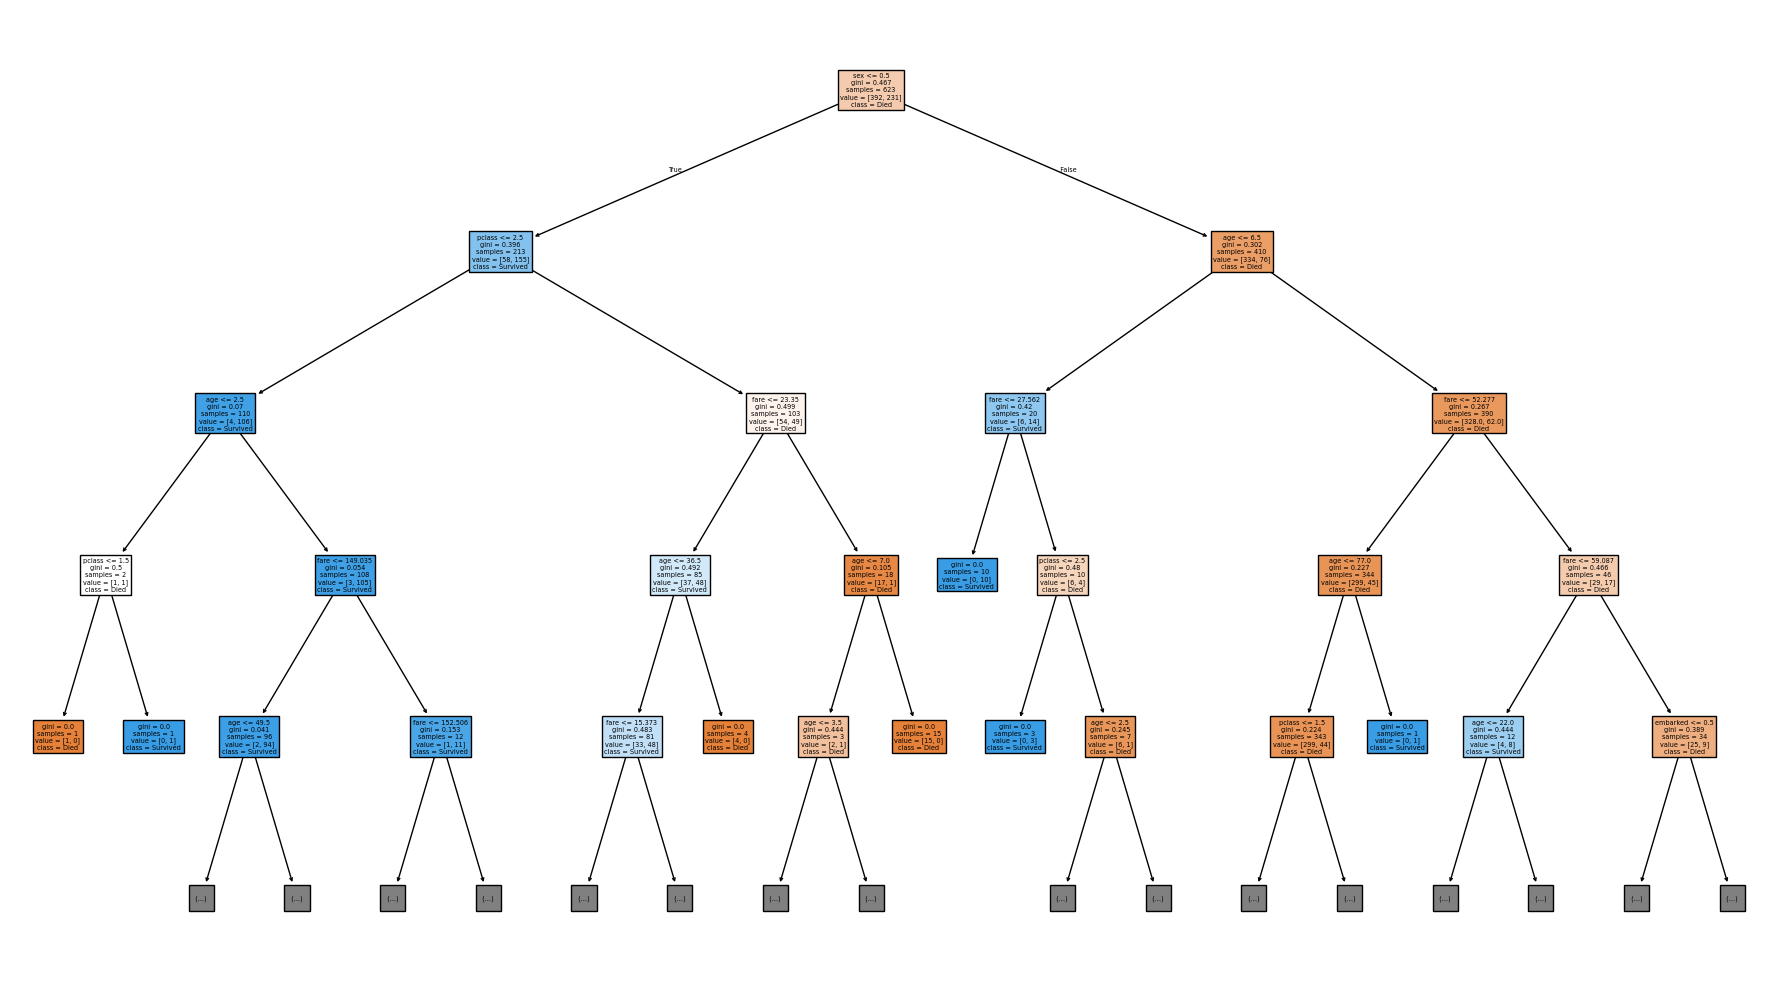

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True,
    max_depth = 4 # be4 its depth is more for clear we we took max depth as 4
)

plt.tight_layout()
plt.show()

# Decision tree with pre-pruning

for depth=2, accuracy=0.7723880597014925
for depth=3, accuracy=0.8059701492537313
for depth=4, accuracy=0.8246268656716418


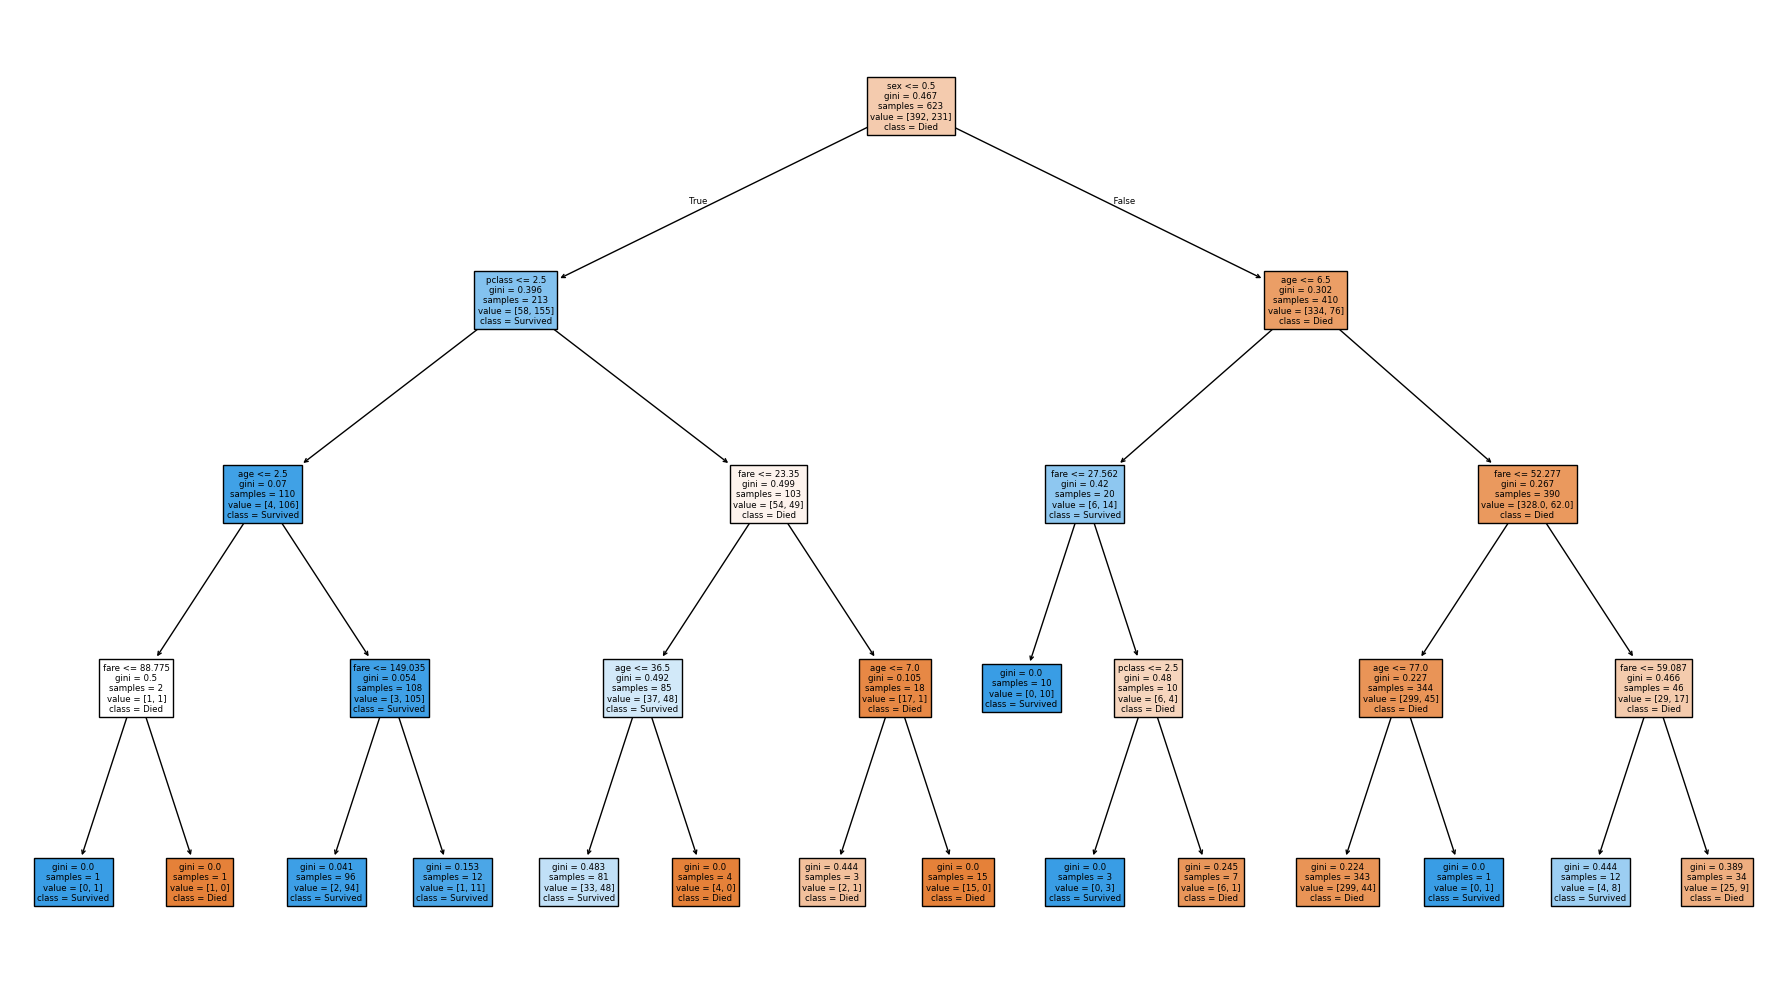

for depth=5, accuracy=0.7947761194029851
for depth=6, accuracy=0.7873134328358209
for depth=7, accuracy=0.7798507462686567
for depth=8, accuracy=0.8022388059701493
for depth=9, accuracy=0.7723880597014925
for depth=10, accuracy=0.7947761194029851


In [15]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train, y_train)

    acc= model.score(X_test, y_test)
    print(f"for depth={depth}, accuracy={acc}")

    if depth == 4:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died", "Survived"],
            filled = True
        )
        
        plt.tight_layout()
        plt.show()

for sample split=10, accuracy=0.8246268656716418


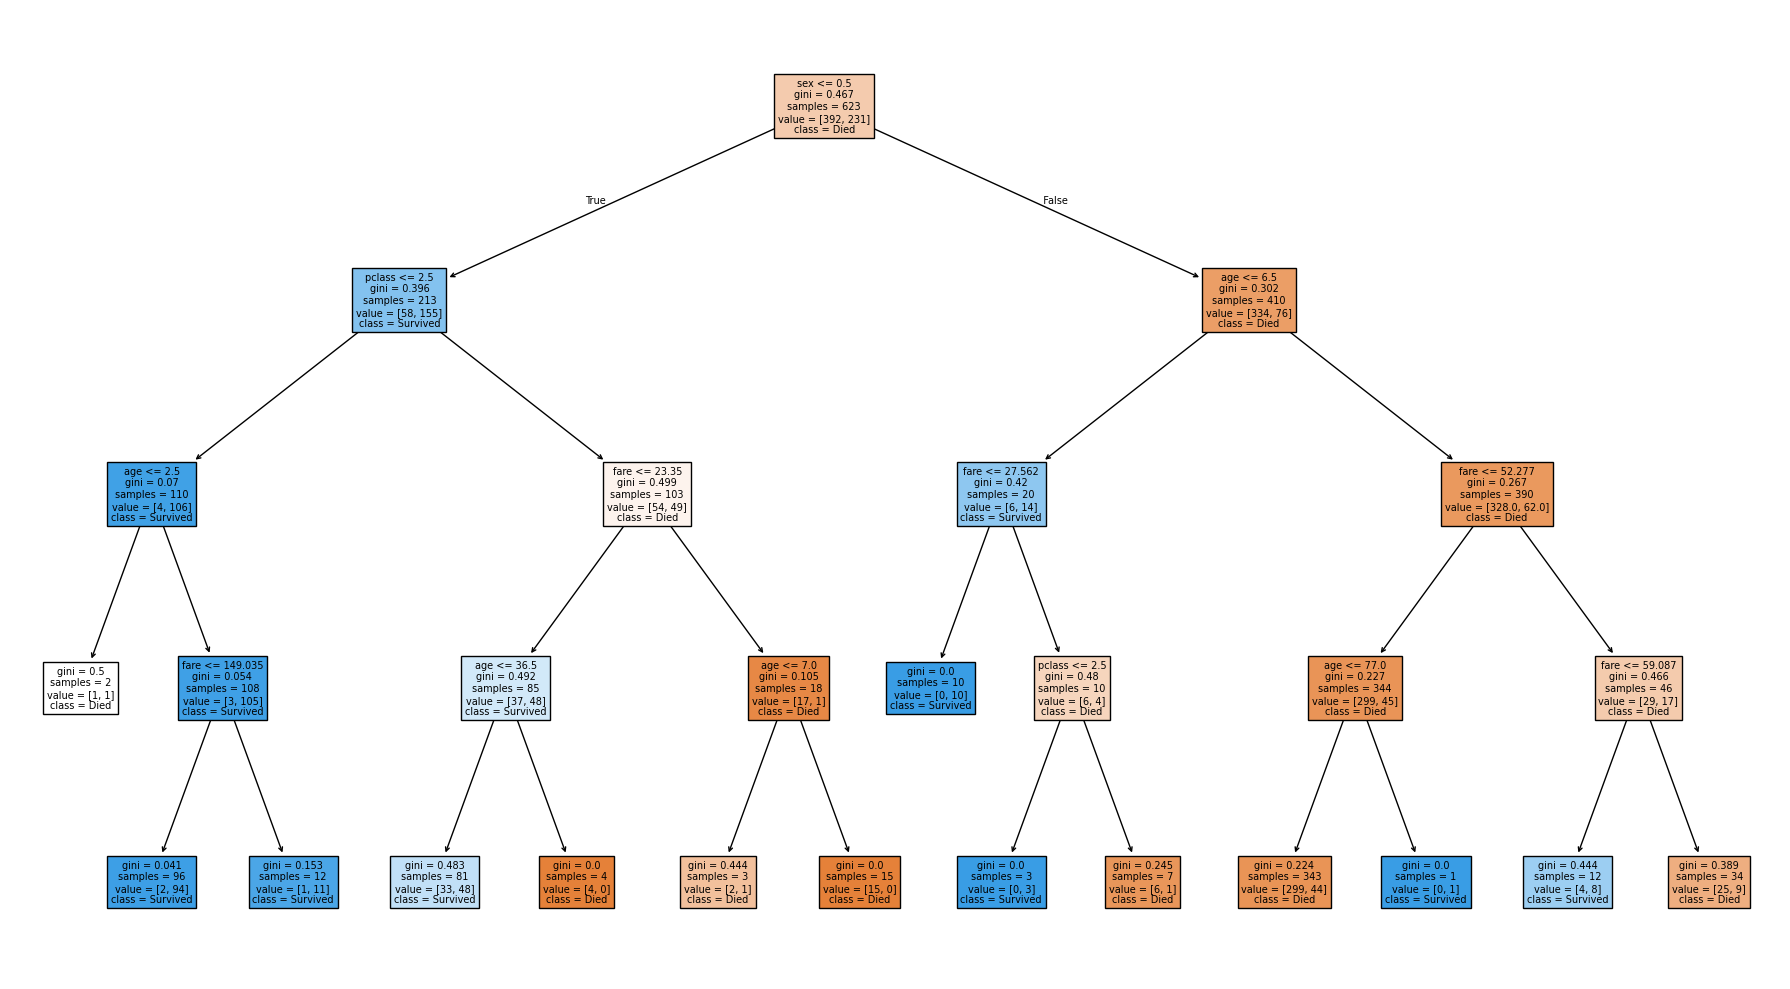

for sample split=15, accuracy=0.8171641791044776
for sample split=20, accuracy=0.8171641791044776
for sample split=25, accuracy=0.8208955223880597
for sample split=30, accuracy=0.8208955223880597


In [16]:
min_samples_splits = [10, 15, 20, 25, 30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth = 4, min_samples_split = split) # as we got to know its acc is more
    model.fit(X_train, y_train)

    acc= model.score(X_test, y_test)
    print(f"for sample split={split}, accuracy={acc}")

    if split == 10: # as split of 10 has good acc
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died", "Survived"],
            filled = True
        )
        
        plt.tight_layout()
        plt.show()

# Decision Tree with Post-Pruning

In [17]:
full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [19]:
# train our model for all alphas

trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42, ccp_alpha = alpha)
    model.fit(X_train, y_train)

    trees.append((model, alpha))

In [20]:
best_acc = 0
best_alpha = 0

for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)

    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [21]:
best_alpha

np.float64(0.0017121455323702516)

In [22]:
best_acc

0.8208955223880597

In [23]:
best_model = DecisionTreeClassifier(ccp_alpha = best_alpha)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0017121455323702516))

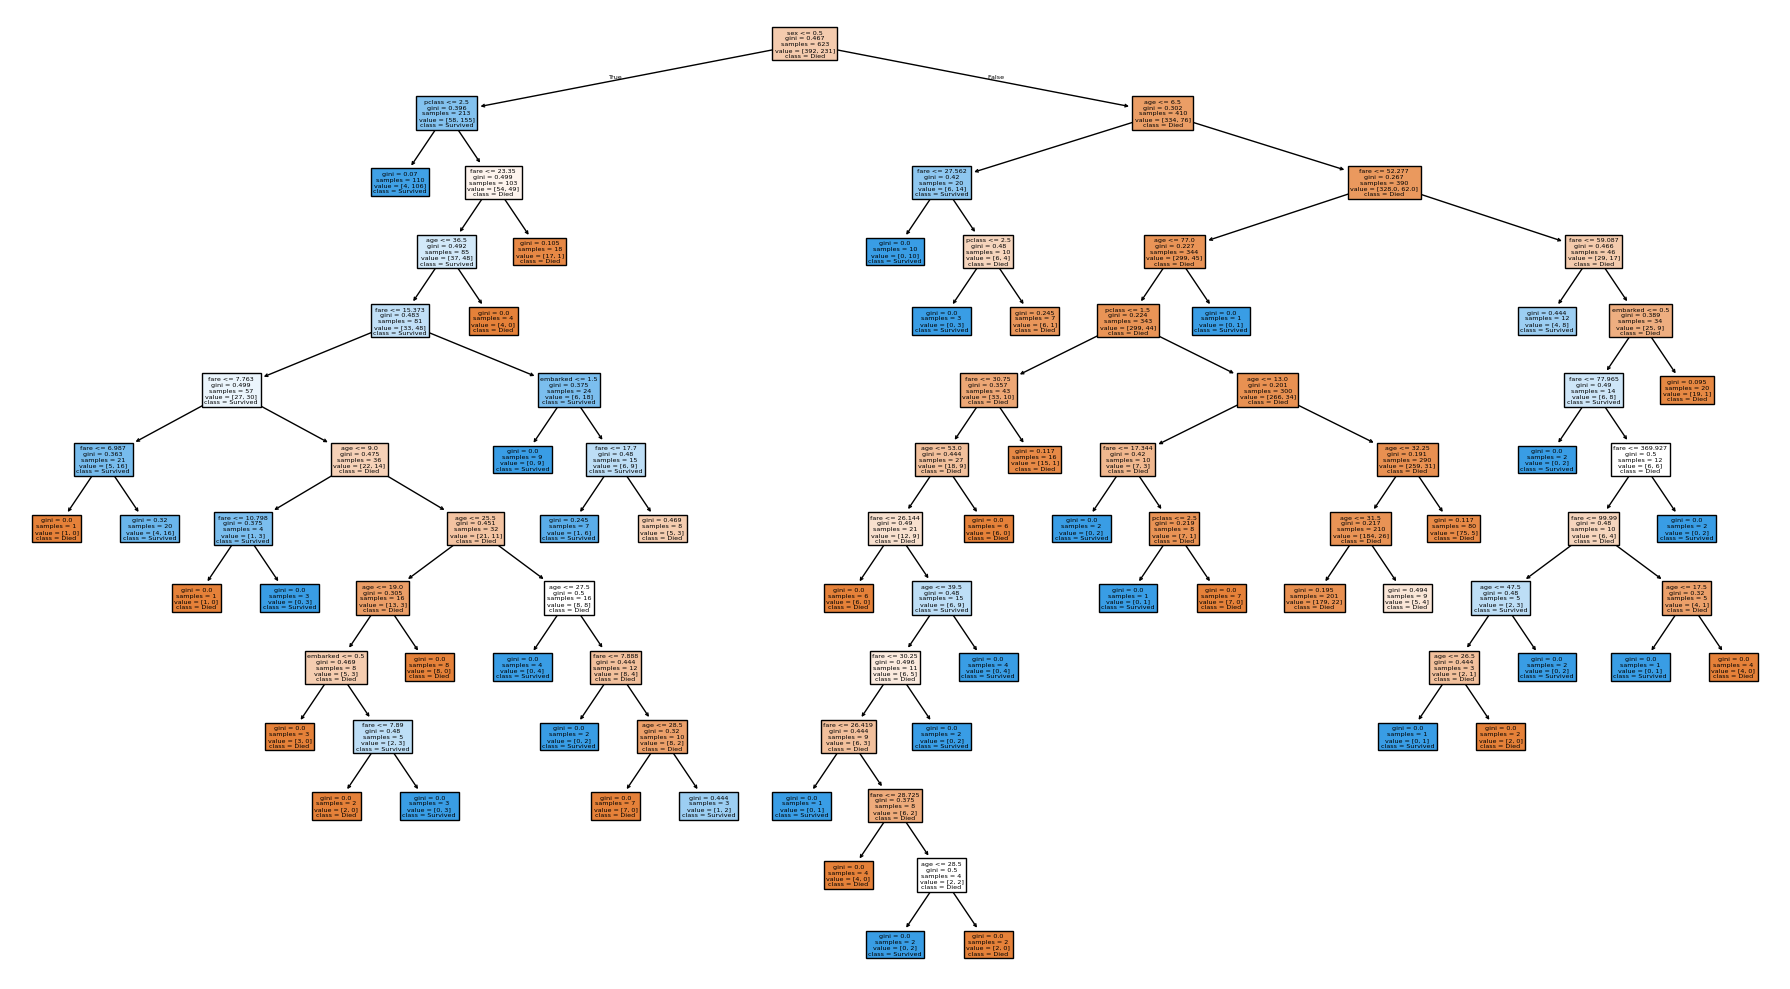

In [24]:
plt.figure(figsize=(18,10))
plot_tree(
            best_model,
            feature_names = X.columns,
            class_names = ["Died", "Survived"],
            filled = True
        )
plt.tight_layout()
plt.show()

In [25]:
print(best_model.score(X_test, y_test))

0.8134328358208955
